<a href="https://colab.research.google.com/github/aryaeva16-svg/Regression-Dataset/blob/main/DecisonTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas scikit-learn numpy matplotlib seaborn

In [3]:
from google.colab import files
uploaded = files.upload()

Saving adult_income.csv to adult_income.csv


In [4]:
import pandas as pd

# Replace with your file name
df = pd.read_csv("adult_income.csv")

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [18]:
df.replace("?", pd.NA, inplace=True)
df.dropna(inplace=True)
df.columns = df.columns.str.strip()
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

df["income"] = df["income"].replace({
    "<=50K": 0,
    ">50K": 1
})

print(df["income"].unique())

/tmp/ipykernel_4591/2350138427.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


[0 1]


In [19]:
continuous_cols = [
    "age",
    "fnlwgt",
    "educational-num",   # check column name matches your file
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

In [20]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

def entropy_discretize(df, column, target, max_leaf_nodes=4):
    X = df[[column]].astype(float).values
    y = df[target].astype(int).values

    tree = DecisionTreeClassifier(
        criterion="entropy",
        max_leaf_nodes=max_leaf_nodes,
        random_state=42
    )
    tree.fit(X, y)

    thresholds = tree.tree_.threshold
    thresholds = thresholds[thresholds != -2]

    if len(thresholds) == 0:
        return df[column]  # no split case

    thresholds = sorted(thresholds)

    bins = [-np.inf] + thresholds + [np.inf]

    return pd.cut(df[column], bins=bins, labels=False)

# Apply
for col in continuous_cols:
    df[col] = entropy_discretize(df, col, "income")

In [21]:
df_encoded = pd.get_dummies(df)
df_encoded = df_encoded.apply(pd.to_numeric)

X = df_encoded.drop("income", axis=1)
y = df_encoded["income"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [24]:
from sklearn.metrics import accuracy_score

y_pred = dt.predict(X_test)

print("Before Pruning")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Tree Depth:", dt.get_depth())
print("Number of Leaves:", dt.get_n_leaves())

Before Pruning
Accuracy: 0.8334991708126036
Tree Depth: 46
Number of Leaves: 5239


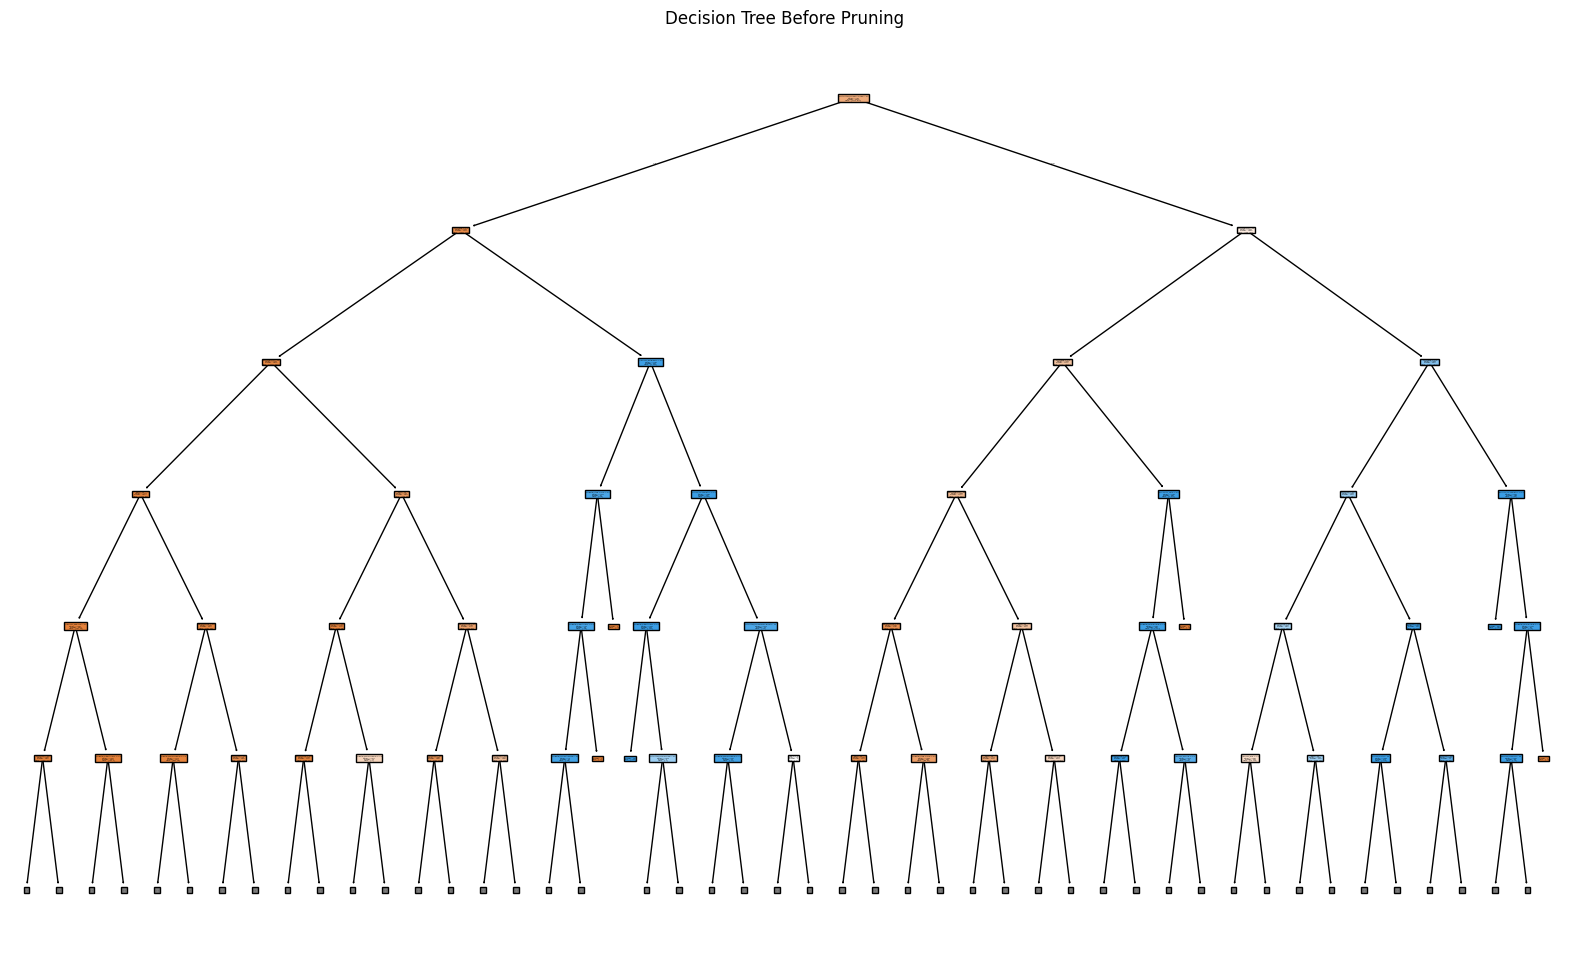

In [34]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,12))
plot_tree(dt, filled=True, feature_names=X.columns, max_depth=5)
plt.title("Decision Tree Before Pruning")
plt.show()

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np

path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

ccp_alphas = ccp_alphas[1:]

ccp_alphas = ccp_alphas[::10]

models = []
accuracies = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(
        criterion="entropy",
        ccp_alpha=float(alpha),
        max_depth=10,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    models.append(model)
    accuracies.append(acc)

best_index = np.argmax(accuracies)

if best_index == 0 and len(accuracies) > 1:
    best_index = 1

best_model = models[best_index]

print("After Pruning Results")
print("Best alpha:", ccp_alphas[best_index])
print("Accuracy:", accuracies[best_index])
print("Tree Depth:", best_model.get_depth())
print("Leaves:", best_model.get_n_leaves())

After Pruning Results
Best alpha: 0.0001384457313737264
Accuracy: 0.8619126589275843
Tree Depth: 10
Leaves: 127


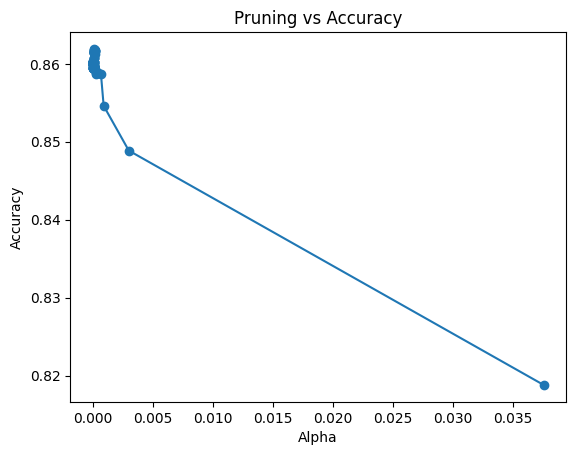

In [28]:
import matplotlib.pyplot as plt

plt.plot(ccp_alphas, accuracies, marker='o')
plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.title("Pruning vs Accuracy")
plt.show()

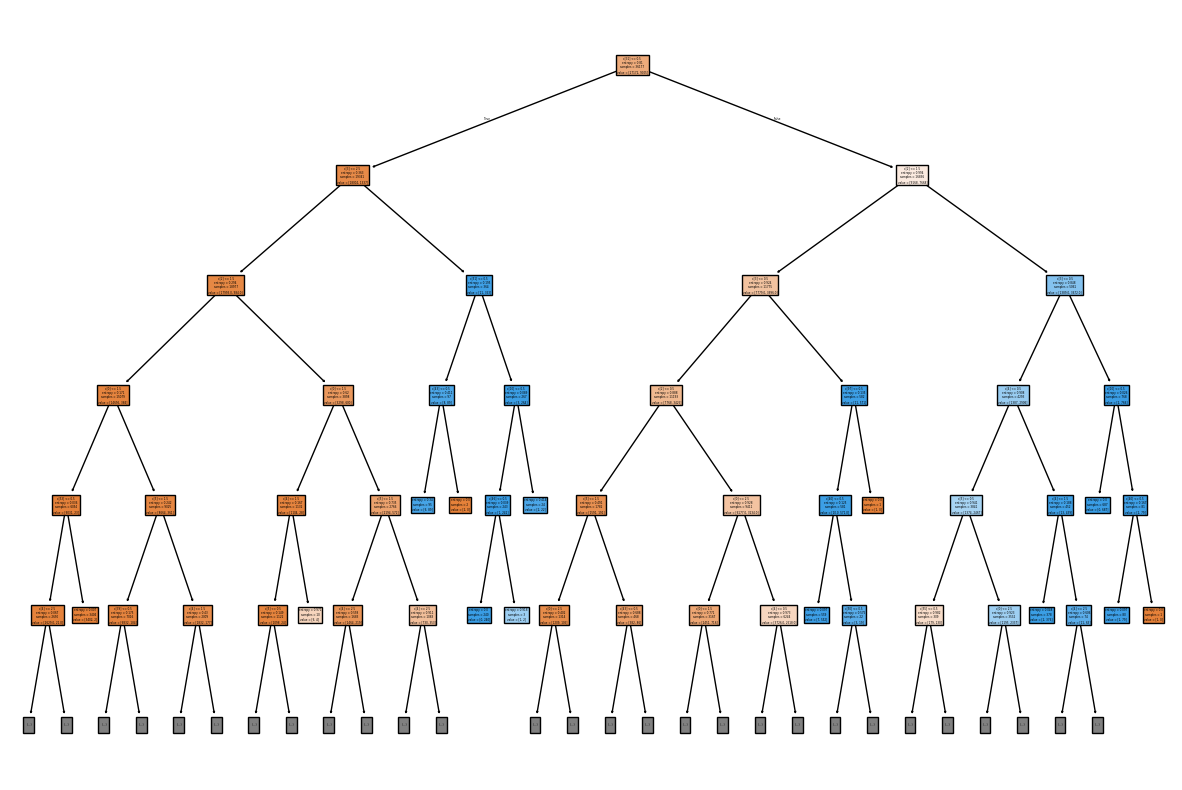

In [33]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(best_model, filled=True, max_depth=5)
plt.show()